In [1]:
import xarray as xr
ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_5_onestep_l1_nofc_aheadtop_5_addprecipnorm/prcp_downs_unet_year_2020.nc")
ds

FileNotFoundError: [Errno 2] No such file or directory: '/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_5_onestep_l1_nofc_aheadtop_5_addprecipnorm/prcp_downs_unet_year_2020.nc'

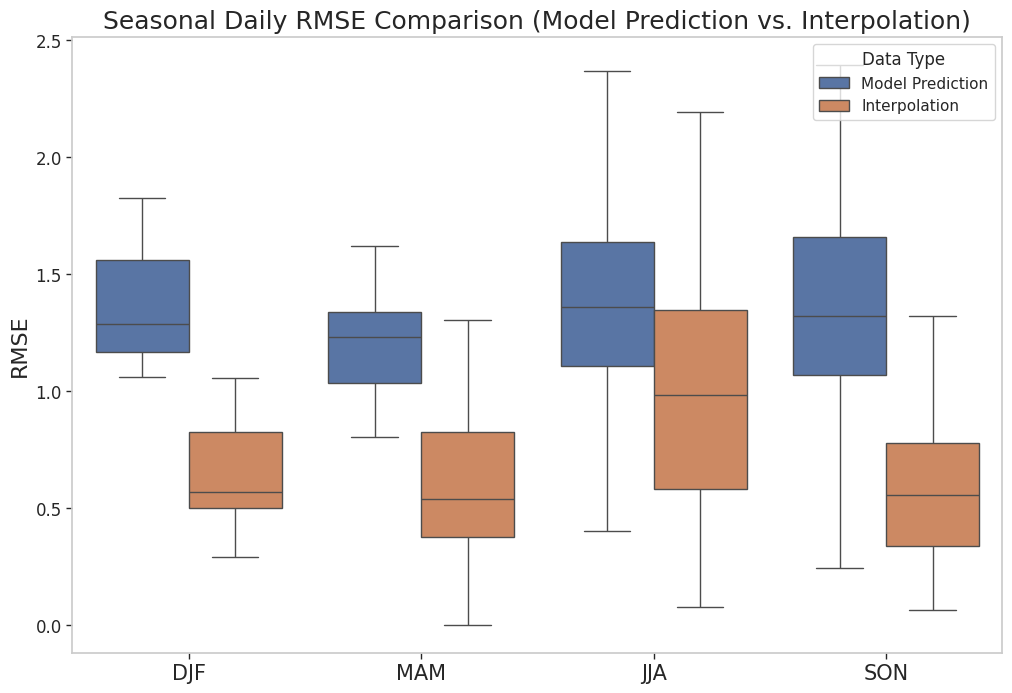

In [11]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 加载数据集
ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex31_7_onestepwgan_cri5_1000_0_l1_aheadtop_10_180epoch_addprecipnorm/prcp_downs_wgan_year_2020.nc")

# 提取变量
fcst = ds['fcst']  # 模型预测结果
hr = ds['hr']      # 高分辨率雷达观测
inter = ds['inter']  # 双三线插值结果
time = pd.to_datetime(ds['time'].values)  # 时间坐标

# 计算按天 RMSE 函数
def calculate_daily_rmse(pred, obs):
    daily_rmse = []
    pred_grouped = pred.groupby('time.date')
    obs_grouped = obs.groupby('time.date')

    for day in pred_grouped.groups:
        pred_data = pred_grouped[day].values.reshape(-1)
        obs_data = obs_grouped[day].values.reshape(-1)
        
        # 计算 RMSE，避免无效数据
        if np.all(np.isnan(pred_data)) or np.all(np.isnan(obs_data)):
            continue
        
        rmse = np.sqrt(np.mean((pred_data - obs_data) ** 2))
        daily_rmse.append({'date': day, 'rmse': rmse})
    
    return pd.DataFrame(daily_rmse)

# 计算 fcst 和 inter 相对于 hr 的 RMSE
df_fcst = calculate_daily_rmse(fcst, hr)
df_inter = calculate_daily_rmse(inter, hr)

# 添加模型类型
df_fcst['Type'] = 'Model Prediction'
df_inter['Type'] = 'Interpolation'
df = pd.concat([df_fcst, df_inter])

# 将日期转换为 datetime 格式
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month

# 季节映射
def get_season(month):
    if month in [12, 1, 2]:
        return 'DJF'  # 冬季：December, January, February
    elif month in [3, 4, 5]:
        return 'MAM'  # 春季：March, April, May
    elif month in [6, 7, 8]:
        return 'JJA'  # 夏季：June, July, August
    else:
        return 'SON'  # 秋季：September, October, November

df['season'] = df['month'].map(get_season)

# 设置绘图风格
sns.set(style="whitegrid")

# 绘制箱线图，禁用离群点
plt.figure(figsize=(12, 8))
sns.boxplot(x='season', y='rmse', hue='Type', data=df,
            order=['DJF', 'MAM', 'JJA', 'SON'],
            showfliers=False)  # 不显示离群点

# 美化图表
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.title('Seasonal Daily RMSE Comparison (Model Prediction vs. Interpolation)', fontsize=18)
plt.xlabel('')  
plt.ylabel('RMSE', fontsize=16)

plt.xticks(fontsize=15)
plt.yticks(fontsize=12)

# 关闭网格线但保留刻度线
plt.grid(False)  
plt.tick_params(axis='x', which='both', bottom=True, top=False)  # 保留X轴刻度
plt.tick_params(axis='y', which='both', left=True, right=False)  # 保留Y轴刻度

# 设置小刻度
plt.gca().tick_params(axis='both', which='major', length=4, width=1)  # 主刻度加长加粗
plt.gca().tick_params(axis='both', which='minor', length=2, width=0.7)  # 小刻度稍短稍细

plt.legend(title='Data Type', loc='upper right')
plt.show()


## 需要老师的check

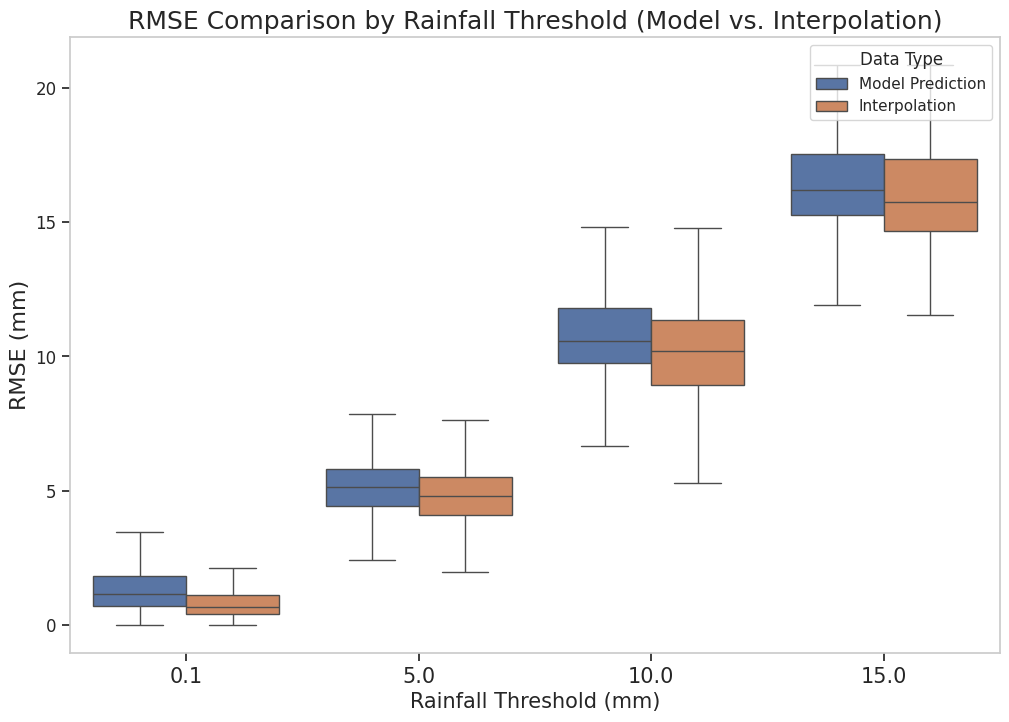

In [9]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample

# 加载数据集
ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex31_7_onestepwgan_cri5_1000_0_l1_aheadtop_10_180epoch_addprecipnorm/prcp_downs_wgan_year_2020.nc")

# 提取变量
fcst = ds['fcst'].values  # 模型预测结果
hr = ds['hr'].values      # 高分辨率雷达观测
inter = ds['inter'].values  # 双三线插值结果
time = pd.to_datetime(ds['time'].values)  # 时间坐标

# 降水强度阈值列表
grade_list = [0.1, 5, 10, 15]

# 计算逐时间片的 RMSE
def calculate_rmse_by_threshold(fcst, hr, grade_list):
    rmse_dict = {grade: [] for grade in grade_list}  # 按阈值存储 RMSE 结果
    
    # 遍历每个时间片，计算不同降水强度下的 RMSE
    for i in range(hr.shape[0]):
        hr_data = hr[i].flatten()
        fcst_data = fcst[i].flatten()
        
        for grade in grade_list:
            # 只计算超过阈值的降水点的 RMSE
            mask = hr_data >= grade
            if np.any(mask):
                rmse = np.sqrt(np.mean((fcst_data[mask] - hr_data[mask]) ** 2))
            else:
                rmse = np.nan  # 如果无降水超过阈值，填充 NaN
            rmse_dict[grade].append(rmse)
    
    return rmse_dict

# 计算模型预测和插值的 RMSE
rmse_fcst = calculate_rmse_by_threshold(fcst, hr, grade_list)
rmse_inter = calculate_rmse_by_threshold(inter, hr, grade_list)

# **解决长度不一致问题**
def pad_dict_to_same_length(rmse_dict):
    max_length = max(len(v) for v in rmse_dict.values())  # 找到最大长度
    for k, v in rmse_dict.items():
        if len(v) < max_length:
            v.extend([np.nan] * (max_length - len(v)))  # 填充 NaN
    return rmse_dict

# 对 FCST 和 INTER 的字典进行填充
rmse_fcst = pad_dict_to_same_length(rmse_fcst)
rmse_inter = pad_dict_to_same_length(rmse_inter)

# 将 RMSE 结果转换为 DataFrame
df_fcst = pd.DataFrame(rmse_fcst).melt(var_name='Threshold', value_name='RMSE')
df_fcst['Type'] = 'Model Prediction'

df_inter = pd.DataFrame(rmse_inter).melt(var_name='Threshold', value_name='RMSE')
df_inter['Type'] = 'Interpolation'

df = pd.concat([df_fcst, df_inter])  # 合并两个结果

# **去除 NaN 以避免绘图错误**
df = df.dropna(subset=['RMSE']) 

# 设置绘图风格
sns.set(style="whitegrid")

# 绘制箱线图（不同降水阈值下的 RMSE 比较）
plt.figure(figsize=(12, 8))
sns.boxplot(x='Threshold', y='RMSE', hue='Type', data=df,
            showfliers=False)  # 不显示离群点

# 美化图表
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.title('RMSE Comparison by Rainfall Threshold (Model vs. Interpolation)', fontsize=18)
plt.xlabel('Rainfall Threshold (mm)', fontsize=15)  
plt.ylabel('RMSE (mm)', fontsize=16)

plt.xticks(fontsize=15)
plt.yticks(fontsize=12)

plt.grid(False)  
plt.tick_params(axis='x', which='both', bottom=True, top=False)  # 保留X轴刻度
plt.tick_params(axis='y', which='both', left=True, right=False)  # 保留Y轴刻度

plt.legend(title='Data Type', loc='upper right')
plt.show()


## 需要老师的check

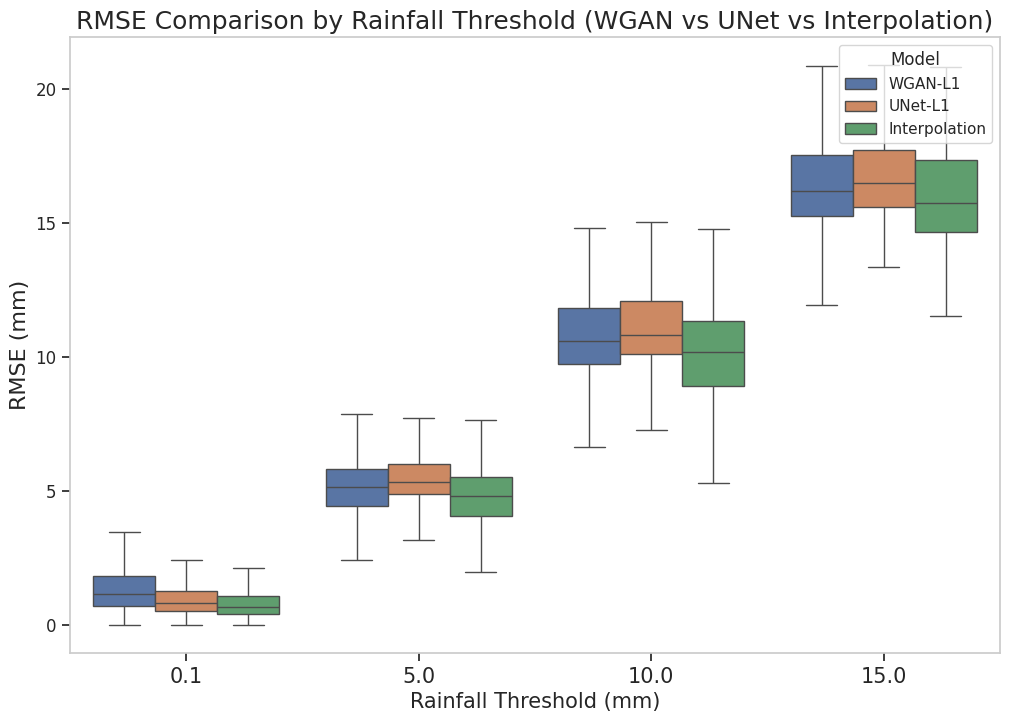

In [10]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 加载 WGAN-L1 数据集
ds_wgan = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex31_7_onestepwgan_cri5_1000_0_l1_aheadtop_10_180epoch_addprecipnorm/prcp_downs_wgan_year_2020.nc")
fcst_wgan = ds_wgan['fcst'].values
hr_wgan = ds_wgan['hr'].values
inter = ds_wgan['inter'].values 

# 加载 UNet-L1 数据集
ds_unet = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_13_onestep_l1_nofc_aheadtop_10_addprecipnorm/prcp_downs_unet_year_2020.nc")
fcst_unet = ds_unet['fcst'].values
hr_unet = ds_unet['hr'].values

# 降水强度阈值列表
grade_list = [0.1, 5, 10, 15]

# 计算逐时间片的 RMSE
def calculate_rmse_by_threshold(fcst, hr, grade_list):
    rmse_dict = {grade: [] for grade in grade_list}  # 按阈值存储 RMSE 结果
    
    # 遍历每个时间片，计算不同降水强度下的 RMSE
    for i in range(hr.shape[0]):
        hr_data = hr[i].flatten()
        fcst_data = fcst[i].flatten()
        
        for grade in grade_list:
            # 只计算超过阈值的降水点的 RMSE
            mask = hr_data >= grade
            if np.any(mask):
                rmse = np.sqrt(np.mean((fcst_data[mask] - hr_data[mask]) ** 2))
            else:
                rmse = np.nan  # 如果无降水超过阈值，填充 NaN
            rmse_dict[grade].append(rmse)
    
    return rmse_dict

# 计算 WGAN 和 UNet 的 RMSE
rmse_fcst_wgan = calculate_rmse_by_threshold(fcst_wgan, hr_wgan, grade_list)
rmse_fcst_unet = calculate_rmse_by_threshold(fcst_unet, hr_unet, grade_list)
rmse_inter = calculate_rmse_by_threshold(inter, hr_wgan, grade_list)  # 插值基于 WGAN hr

# 解决长度不一致问题
def pad_dict_to_same_length(rmse_dict):
    max_length = max(len(v) for v in rmse_dict.values())
    for k, v in rmse_dict.items():
        if len(v) < max_length:
            v.extend([np.nan] * (max_length - len(v)))
    return rmse_dict

rmse_fcst_wgan = pad_dict_to_same_length(rmse_fcst_wgan)
rmse_fcst_unet = pad_dict_to_same_length(rmse_fcst_unet)
rmse_inter = pad_dict_to_same_length(rmse_inter)

# 转换为 DataFrame
df_wgan = pd.DataFrame(rmse_fcst_wgan).melt(var_name='Threshold', value_name='RMSE')
df_wgan['Type'] = 'WGAN-L1'

df_unet = pd.DataFrame(rmse_fcst_unet).melt(var_name='Threshold', value_name='RMSE')
df_unet['Type'] = 'UNet-L1'

df_inter = pd.DataFrame(rmse_inter).melt(var_name='Threshold', value_name='RMSE')
df_inter['Type'] = 'Interpolation'

df = pd.concat([df_wgan, df_unet, df_inter])  # 合并三个结果

# 去除 NaN
df = df.dropna(subset=['RMSE'])

sns.set(style="whitegrid")

# 绘制箱线图
plt.figure(figsize=(12, 8))
sns.boxplot(x='Threshold', y='RMSE', hue='Type', data=df, showfliers=False)  # 不显示离群点

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.title('RMSE Comparison by Rainfall Threshold (WGAN vs UNet vs Interpolation)', fontsize=18)
plt.xlabel('Rainfall Threshold (mm)', fontsize=15)
plt.ylabel('RMSE (mm)', fontsize=16)

plt.xticks(fontsize=15)
plt.yticks(fontsize=12)

plt.grid(False)
plt.tick_params(axis='x', which='both', bottom=True, top=False)
plt.tick_params(axis='y', which='both', left=True, right=False)

plt.legend(title='Model', loc='upper right')
plt.show()


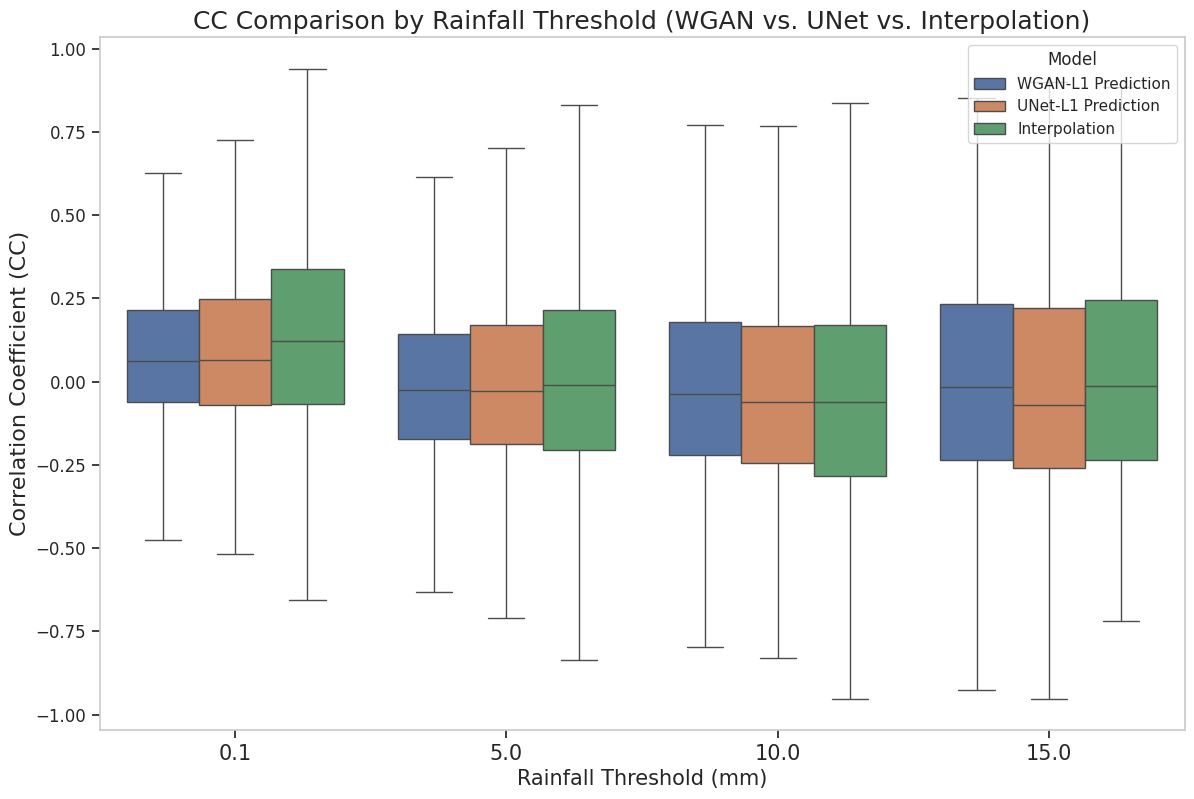

In [11]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 降水强度阈值列表
grade_list = [0.1, 5, 10, 15]

# 计算按降水强度的 CC 函数
def calculate_cc_by_threshold(fcst, hr, grade_list):
    cc_dict = {grade: [] for grade in grade_list}  
    
    # 遍历每个时间片，计算不同降水强度下的 CC
    for i in range(hr.shape[0]):
        hr_data = hr[i].flatten()
        fcst_data = fcst[i].flatten()
        
        for grade in grade_list:
            # 只计算超过阈值的降水点的 CC
            mask = hr_data >= grade
            if np.any(mask):
                # 避免标准差为0导致的除零错误
                if np.std(fcst_data[mask]) > 0 and np.std(hr_data[mask]) > 0:
                    cc = np.corrcoef(fcst_data[mask], hr_data[mask])[0, 1]
                else:
                    cc = np.nan  # 如果标准差为0，返回 NaN
            else:
                cc = np.nan  # 如果无降水超过阈值，填充 NaN
            cc_dict[grade].append(cc)
    
    return cc_dict

# 加载 WGAN-L1 数据集
ds_wgan = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex31_7_onestepwgan_cri5_1000_0_l1_aheadtop_10_180epoch_addprecipnorm/prcp_downs_wgan_year_2020.nc")
fcst_wgan = ds_wgan['fcst'].values
hr_wgan = ds_wgan['hr'].values
inter = ds_wgan['inter'].values  

# 加载 UNet-L1 数据集
ds_unet = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_13_onestep_l1_nofc_aheadtop_10_addprecipnorm/prcp_downs_unet_year_2020.nc")
fcst_unet = ds_unet['fcst'].values
hr_unet = ds_unet['hr'].values

# 计算不同模型的 CC
cc_fcst_wgan = calculate_cc_by_threshold(fcst_wgan, hr_wgan, grade_list)
cc_fcst_unet = calculate_cc_by_threshold(fcst_unet, hr_unet, grade_list)
cc_inter = calculate_cc_by_threshold(inter, hr_wgan, grade_list) 

# 解决长度不一致问题
def pad_dict_to_same_length(cc_dict):
    max_length = max(len(v) for v in cc_dict.values())
    for k, v in cc_dict.items():
        if len(v) < max_length:
            v.extend([np.nan] * (max_length - len(v)))
    return cc_dict

cc_fcst_wgan = pad_dict_to_same_length(cc_fcst_wgan)
cc_fcst_unet = pad_dict_to_same_length(cc_fcst_unet)
cc_inter = pad_dict_to_same_length(cc_inter)

# 转换为 DataFrame
df_wgan = pd.DataFrame(cc_fcst_wgan).melt(var_name='Threshold', value_name='CC')
df_wgan['Type'] = 'WGAN-L1 Prediction'

df_unet = pd.DataFrame(cc_fcst_unet).melt(var_name='Threshold', value_name='CC')
df_unet['Type'] = 'UNet-L1 Prediction'

df_inter = pd.DataFrame(cc_inter).melt(var_name='Threshold', value_name='CC')
df_inter['Type'] = 'Interpolation'

# 合并数据
df = pd.concat([df_wgan, df_unet, df_inter])

# 去除 NaN
df = df.dropna(subset=['CC'])

# 设置绘图风格
sns.set(style="whitegrid")

# 绘制箱线图
plt.figure(figsize=(14, 9))
sns.boxplot(x='Threshold', y='CC', hue='Type', data=df,
            showfliers=False)  # 不显示离群点

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.title('CC Comparison by Rainfall Threshold (WGAN vs. UNet vs. Interpolation)', fontsize=18)
plt.xlabel('Rainfall Threshold (mm)', fontsize=15)
plt.ylabel('Correlation Coefficient (CC)', fontsize=16)

plt.xticks(fontsize=15)
plt.yticks(fontsize=12)

plt.grid(False)
plt.tick_params(axis='x', which='both', bottom=True)
plt.tick_params(axis='y', which='both', left=True)

plt.legend(title='Model', loc='upper right')
plt.show()


## 需要老师check

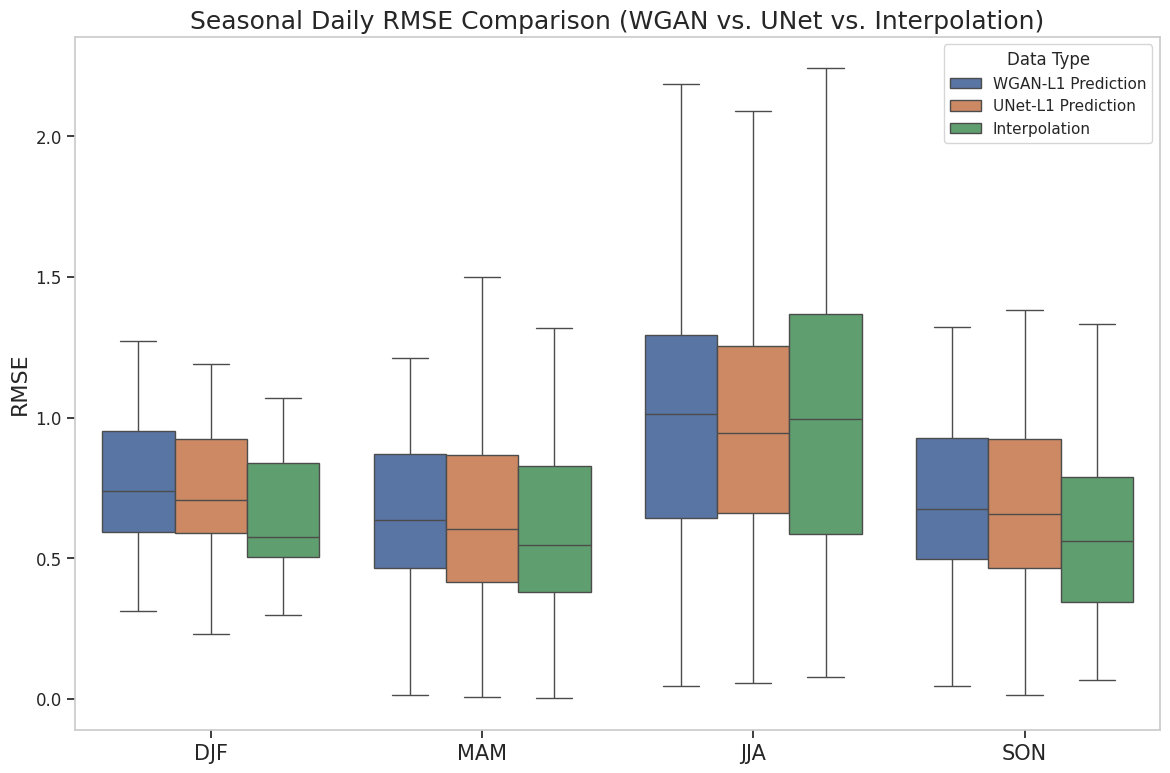

In [12]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 计算按天 RMSE 函数
def calculate_daily_rmse(pred, obs):
    daily_rmse = []
    pred_grouped = pred.groupby('time.date')
    obs_grouped = obs.groupby('time.date')

    for day in pred_grouped.groups:
        pred_data = pred_grouped[day].values.reshape(-1)
        obs_data = obs_grouped[day].values.reshape(-1)
        
        # 避免无效数据
        if np.all(np.isnan(pred_data)) or np.all(np.isnan(obs_data)):
            continue
        
        rmse = np.sqrt(np.mean((pred_data - obs_data) ** 2))
        daily_rmse.append({'date': day, 'rmse': rmse})
    
    return pd.DataFrame(daily_rmse)

# 加载 WGAN-L1 数据集
ds_wgan = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex31_8_onestepwgan_cri5_100_0_l1_aheadtop_10_180epoch_addprecipnorm/prcp_downs_wgan_year_2020.nc")
fcst_wgan = ds_wgan['fcst']
hr_wgan = ds_wgan['hr']
inter = ds_wgan['inter'] 
# 加载 UNet-L1 数据集
ds_unet = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_13_onestep_l1_nofc_aheadtop_10_addprecipnorm/prcp_downs_unet_year_2020.nc")
fcst_unet = ds_unet['fcst']
hr_unet = ds_unet['hr']

# 计算 RMSE
df_fcst_wgan = calculate_daily_rmse(fcst_wgan, hr_wgan)
df_fcst_unet = calculate_daily_rmse(fcst_unet, hr_unet)
df_inter = calculate_daily_rmse(inter, hr_wgan)  # 使用 wgan 的 hr 进行对比

# 添加模型类型和来源
df_fcst_wgan['Type'] = 'WGAN-L1 Prediction'
df_fcst_unet['Type'] = 'UNet-L1 Prediction'
df_inter['Type'] = 'Interpolation'

# 合并数据
df = pd.concat([df_fcst_wgan, df_fcst_unet, df_inter])

# 转换日期格式
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month

# 季节映射
def get_season(month):
    if month in [12, 1, 2]:
        return 'DJF'  # 冬季
    elif month in [3, 4, 5]:
        return 'MAM'  # 春季
    elif month in [6, 7, 8]:
        return 'JJA'  # 夏季
    else:
        return 'SON'  # 秋季

df['season'] = df['month'].map(get_season)

# 设置绘图风格
sns.set(style="whitegrid")

# 绘制箱线图
plt.figure(figsize=(14, 9))
sns.boxplot(x='season', y='rmse', hue='Type', data=df,
            order=['DJF', 'MAM', 'JJA', 'SON'],
            showfliers=False)  # 不显示离群点

# 美化图表
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.title('Seasonal Daily RMSE Comparison (WGAN vs. UNet vs. Interpolation)', fontsize=18)
plt.xlabel('')  
plt.ylabel('RMSE', fontsize=16)

plt.xticks(fontsize=15)
plt.yticks(fontsize=12)

# 美化细节
plt.grid(False)  
plt.tick_params(axis='x', which='both', bottom=True)
plt.tick_params(axis='y', which='both', left=True)

plt.legend(title='Data Type', loc='upper right')
plt.show()


## 需要老师check

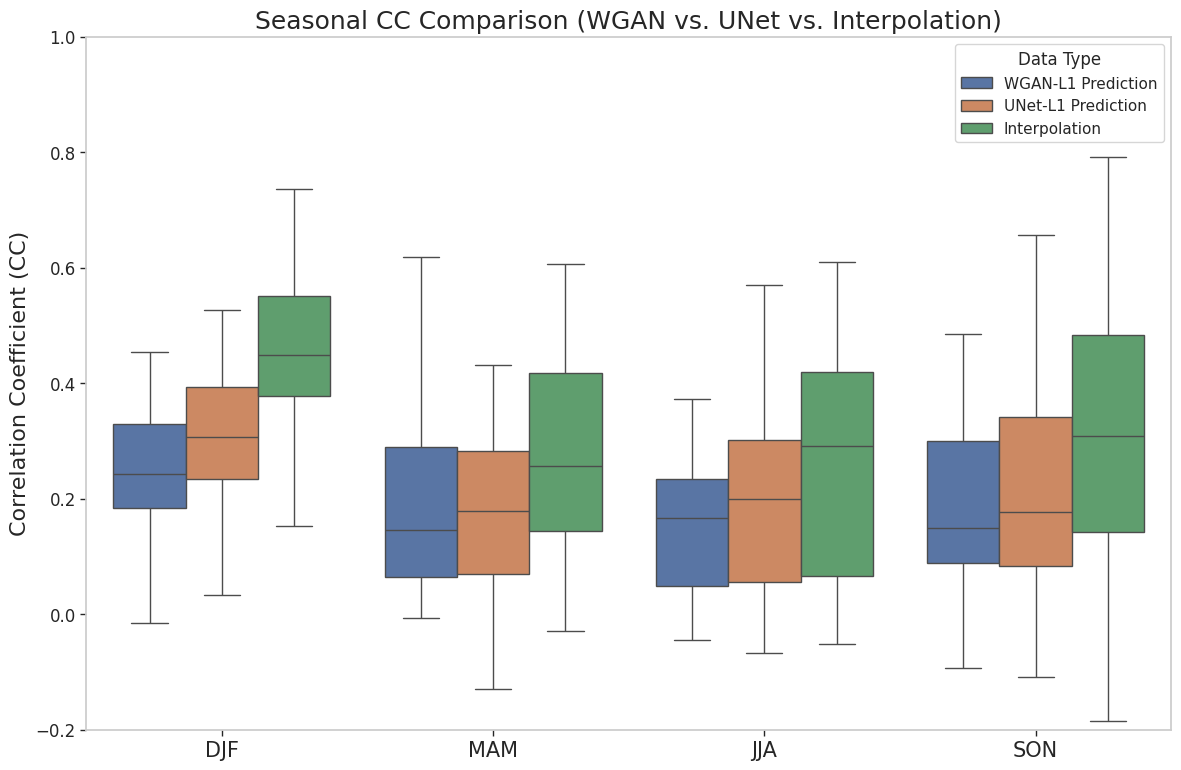

In [13]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 计算按天 CC（相关系数）函数
def calculate_daily_cc(pred, obs):
    daily_cc = []
    
    # 按天分组
    pred_grouped = pred.groupby('time.date')
    obs_grouped = obs.groupby('time.date')

    for day in pred_grouped.groups:
        pred_data = pred_grouped[day]
        obs_data = obs_grouped[day]

        # 展平数据
        pred_flat = pred_data.values.reshape(-1)
        obs_flat = obs_data.values.reshape(-1)
        
        # 避免标准差为零导致 NaN
        if np.std(pred_flat) == 0 or np.std(obs_flat) == 0:
            continue
        
        # 计算相关系数
        cc = np.corrcoef(pred_flat, obs_flat)[0, 1]
        
        daily_cc.append({'date': day, 'cc': cc})
    
    return pd.DataFrame(daily_cc)

# 加载 WGAN-L1 数据集
ds_wgan = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex31_8_onestepwgan_cri5_100_0_l1_aheadtop_10_180epoch_addprecipnorm/prcp_downs_wgan_year_2020.nc")
fcst_wgan = ds_wgan['fcst']
hr_wgan = ds_wgan['hr']
inter = ds_wgan['inter']  

# 加载 UNet-L1 数据集
ds_unet = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_13_onestep_l1_nofc_aheadtop_10_addprecipnorm/prcp_downs_unet_year_2020.nc")
fcst_unet = ds_unet['fcst']
hr_unet = ds_unet['hr']

# 计算相关系数（CC）
df_fcst_wgan = calculate_daily_cc(fcst_wgan, hr_wgan)
df_fcst_unet = calculate_daily_cc(fcst_unet, hr_unet)
df_inter = calculate_daily_cc(inter, hr_wgan) 
# 添加模型类型
df_fcst_wgan['Type'] = 'WGAN-L1 Prediction'
df_fcst_unet['Type'] = 'UNet-L1 Prediction'
df_inter['Type'] = 'Interpolation'

# 合并数据
df = pd.concat([df_fcst_wgan, df_fcst_unet, df_inter])

# 转换日期格式
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month

# 季节映射
def get_season(month):
    if month in [12, 1, 2]:
        return 'DJF'  # 冬季
    elif month in [3, 4, 5]:
        return 'MAM'  # 春季
    elif month in [6, 7, 8]:
        return 'JJA'  # 夏季
    else:
        return 'SON'  # 秋季

df['season'] = df['month'].map(get_season)

sns.set(style="whitegrid")

# 绘制箱线图
plt.figure(figsize=(14, 9))
sns.boxplot(x='season', y='cc', hue='Type', data=df,
            order=['DJF', 'MAM', 'JJA', 'SON'],
            showfliers=False)  # 不显示离群点

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.title('Seasonal CC Comparison (WGAN vs. UNet vs. Interpolation)', fontsize=18)
plt.xlabel('') 
plt.ylabel('Correlation Coefficient (CC)', fontsize=16)
plt.ylim(-0.2, 1)  
plt.legend(title='Data Type', loc='upper right')
plt.xticks(fontsize=15)
plt.yticks(fontsize=12)
plt.grid(False)  
plt.tick_params(axis='x', which='both', bottom=True)
plt.tick_params(axis='y', which='both', left=True)

plt.gca().tick_params(axis='both', which='major', length=4, width=1)  
plt.gca().tick_params(axis='both', which='minor', length=2, width=0.7)  

plt.show()


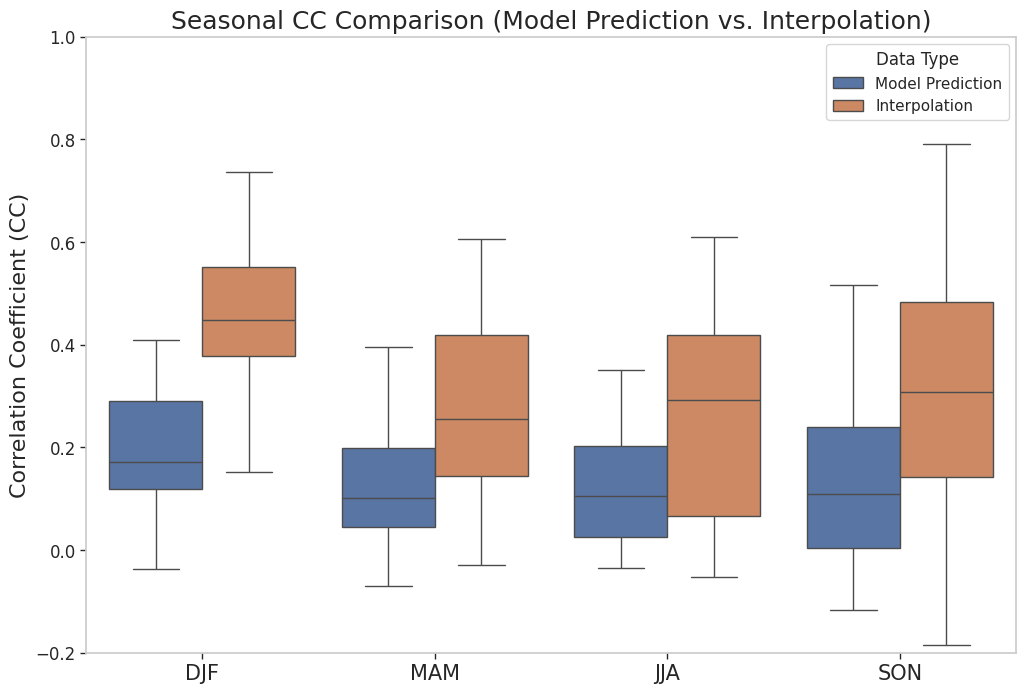

In [13]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 加载数据集
ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex31_7_onestepwgan_cri5_1000_0_l1_aheadtop_10_180epoch_addprecipnorm/prcp_downs_wgan_year_2020.nc")

# 提取变量
fcst = ds['fcst']  # 模型预测结果
hr = ds['hr']      # 高分辨率雷达观测
inter = ds['inter']  # 双三线插值结果
time = pd.to_datetime(ds['time'].values)  # 时间坐标

# 计算每天的相关系数
def calculate_daily_cc(pred, obs):
    daily_cc = []
    
    # 使用groupby分组
    pred_grouped = pred.groupby('time.date')
    obs_grouped = obs.groupby('time.date')

    for day in pred_grouped.groups:
        # 直接迭代获取分组数据
        pred_data = pred_grouped[day]
        obs_data = obs_grouped[day]

        # 展平数据
        pred_flat = pred_data.values.reshape(-1)
        obs_flat = obs_data.values.reshape(-1)
        
        # 处理除零情况，避免NaN
        if np.std(pred_flat) == 0 or np.std(obs_flat) == 0:
            continue  # 跳过标准差为零的情况
        
        # 计算相关系数
        cc = np.corrcoef(pred_flat, obs_flat)[0, 1]
        
        daily_cc.append({'date': day, 'cc': cc})
    
    return pd.DataFrame(daily_cc)

# 计算 fcst 和 inter 相对于 hr 的 CC
df_fcst = calculate_daily_cc(fcst, hr)
df_inter = calculate_daily_cc(inter, hr)

# 合并数据，添加模型类型
df_fcst['Type'] = 'Model Prediction'
df_inter['Type'] = 'Interpolation'
df = pd.concat([df_fcst, df_inter])

# 去除重复索引
df = df.drop_duplicates(subset=['date', 'Type'])

# 将日期转换为 datetime 格式，提取月份和季节
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month

# 季节映射
def get_season(month):
    if month in [12, 1, 2]:
        return 'DJF'  # 冬季
    elif month in [3, 4, 5]:
        return 'MAM'  # 春季
    elif month in [6, 7, 8]:
        return 'JJA'  # 夏季
    else:
        return 'SON'  # 秋季

df['season'] = df['month'].map(get_season)

# 设置绘图风格
sns.set(style="whitegrid")

# 绘制箱线图，禁用离群点
plt.figure(figsize=(12, 8))
sns.boxplot(x='season', y='cc', hue='Type', data=df,
            order=['DJF', 'MAM', 'JJA', 'SON'],
            showfliers=False)  # 不显示离群点

# 美化图表
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.title('Seasonal CC Comparison (Model Prediction vs. Interpolation)', fontsize=18)
plt.xlabel('') 
plt.ylabel('Correlation Coefficient (CC)', fontsize=16)
plt.ylim(-0.2, 1)  
plt.legend(title='Data Type', loc='upper right')
plt.xticks(fontsize=15)
plt.yticks(fontsize=12)
plt.grid(False)  
plt.tick_params(axis='x', which='both', bottom=True, top=False)  
plt.tick_params(axis='y', which='both', left=True, right=False)  

# 设置小刻度
plt.gca().tick_params(axis='both', which='major', length=4, width=1)  
plt.gca().tick_params(axis='both', which='minor', length=2, width=0.7)  

plt.show()


In [6]:
import numpy as np

ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_4_onestep_l1_nofc_aheadtop_10/prcp_downs_unet_year_2020.nc")

inter = ds['inter'].values  # 模型预测结果
hr = ds['hr'].values      # 高分辨率观测数据

# 计算RMSE
rmse = np.sqrt(np.mean((inter - hr) ** 2))

# 计算相关系数（CC）
cc = np.corrcoef(inter.flatten(), hr.flatten())[0, 1]

print(f"RMSE: {rmse:.4f}")
print(f"Correlation Coefficient (CC): {cc:.4f}")


RMSE: 0.9042
Correlation Coefficient (CC): 0.4766


In [13]:
import xarray as xr
import numpy as np

# 加载数据
ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_4_onestep_l1_nofc_aheadtop_10/prcp_downs_unet_year_2020.nc") 

# 计算 Individual Prediction RMSE
mse_individual = ((ds['inter'] - ds['hr']) ** 2).mean(dim=['lat', 'lon'])  # 空间均方误差
rmse_individual = np.sqrt(mse_individual.mean())  # 时间维度平均并开方

# 计算 Ensemble-Mean RMSE
ensemble_mean = ds['inter'].mean(dim='time')  # 集合平均
mse_ensemble_mean = ((ensemble_mean - ds['hr']) ** 2).mean(dim=['lat', 'lon'])  # 空间均方误差
rmse_ensemble_mean = np.sqrt(mse_ensemble_mean.mean())  # 时间维度平均并开方

# 计算相关系数 CC
def calculate_correlation(fcst, hr):
    fcst_mean = fcst.mean(dim=['lat', 'lon'])  # 预测均值
    hr_mean = hr.mean(dim=['lat', 'lon'])      # 真实值均值

    numerator = ((fcst - fcst_mean) * (hr - hr_mean)).sum(dim=['lat', 'lon'])  # 协方差部分
    denominator = np.sqrt(
        ((fcst - fcst_mean) ** 2).sum(dim=['lat', 'lon']) *
        ((hr - hr_mean) ** 2).sum(dim=['lat', 'lon'])
    )  # 标准差乘积

    cc = (numerator / denominator).mean()  # 计算时间平均 CC
    return cc

# 计算并输出 CC
cc_score = calculate_correlation(ds['inter'], ds['hr'])

# 输出结果
print(f"Individual Prediction RMSE (Mean): {rmse_individual.values:.4f}")
print(f"Ensemble-Mean RMSE: {rmse_ensemble_mean.values:.4f}")
print(f"Correlation Coefficient (CC): {cc_score.values:.4f}")


Individual Prediction RMSE (Mean): 0.9042
Ensemble-Mean RMSE: 0.9848
Correlation Coefficient (CC): 0.2073


In [3]:
import numpy as np

ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_4_onestep_l1_nofc_aheadtop_10/prcp_downs_unet_year_2020.nc")

fcst = ds['fcst'].values  # 模型预测结果
hr = ds['hr'].values      # 高分辨率观测数据

# 计算RMSE
rmse = np.sqrt(np.mean((fcst - hr) ** 2))

# 计算相关系数（CC）
cc = np.corrcoef(fcst.flatten(), hr.flatten())[0, 1]

print(f"RMSE: {rmse:.4f}")
print(f"Correlation Coefficient (CC): {cc:.4f}")


RMSE: 0.9987
Correlation Coefficient (CC): 0.2891


In [17]:
import xarray as xr
import numpy as np

# 加载数据
ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_4_onestep_l1_nofc_aheadtop_10/prcp_downs_unet_year_2020.nc") 

# 计算 Individual Prediction RMSE
mse_individual = ((ds['fcst'] - ds['hr']) ** 2).mean(dim=['lat', 'lon'])  # 空间均方误差
rmse_individual = np.sqrt(mse_individual.mean())  # 时间维度平均并开方

# 计算 Ensemble-Mean RMSE
ensemble_mean = ds['fcst'].mean(dim='time')  # 集合平均
mse_ensemble_mean = ((ensemble_mean - ds['hr']) ** 2).mean(dim=['lat', 'lon'])  # 空间均方误差
rmse_ensemble_mean = np.sqrt(mse_ensemble_mean.mean())  # 时间维度平均并开方

# 计算相关系数 CC
def calculate_correlation(fcst, hr):
    fcst_mean = fcst.mean(dim=['lat', 'lon'])  # 预测均值
    hr_mean = hr.mean(dim=['lat', 'lon'])      # 真实值均值

    numerator = ((fcst - fcst_mean) * (hr - hr_mean)).sum(dim=['lat', 'lon'])  # 协方差部分
    denominator = np.sqrt(
        ((fcst - fcst_mean) ** 2).sum(dim=['lat', 'lon']) *
        ((hr - hr_mean) ** 2).sum(dim=['lat', 'lon'])
    )  # 标准差乘积

    cc = (numerator / denominator).mean()  # 计算时间平均 CC
    return cc

# 计算并输出 CC
cc_score = calculate_correlation(ds['fcst'], ds['hr'])

# 输出结果
print(f"Individual Prediction RMSE (Mean): {rmse_individual.values:.4f}")
print(f"Ensemble-Mean RMSE: {rmse_ensemble_mean.values:.4f}")
print(f"Correlation Coefficient (CC): {cc_score.values:.4f}")


Individual Prediction RMSE (Mean): 0.9987
Ensemble-Mean RMSE: 1.0102
Correlation Coefficient (CC): 0.1434


In [4]:
import numpy as np

ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_5_onestep_l1_nofc_aheadtop_5_addprecipnorm/prcp_downs_unet_year_2020.nc")

fcst = ds['fcst'].values  # 模型预测结果
hr = ds['hr'].values      # 高分辨率观测数据

# 计算RMSE
rmse = np.sqrt(np.mean((fcst - hr) ** 2))

# 计算相关系数（CC）
cc = np.corrcoef(fcst.flatten(), hr.flatten())[0, 1]

print(f"RMSE: {rmse:.4f}")
print(f"Correlation Coefficient (CC): {cc:.4f}")


RMSE: 1.6938
Correlation Coefficient (CC): 0.2512


In [15]:
import xarray as xr
import numpy as np

# 加载数据
ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_5_onestep_l1_nofc_aheadtop_5_addprecipnorm/prcp_downs_unet_year_2020.nc") 

# 计算 Individual Prediction RMSE
mse_individual = ((ds['fcst'] - ds['hr']) ** 2).mean(dim=['lat', 'lon'])  # 空间均方误差
rmse_individual = np.sqrt(mse_individual.mean())  # 时间维度平均并开方

# 计算 Ensemble-Mean RMSE
ensemble_mean = ds['fcst'].mean(dim='time')  # 集合平均
mse_ensemble_mean = ((ensemble_mean - ds['hr']) ** 2).mean(dim=['lat', 'lon'])  # 空间均方误差
rmse_ensemble_mean = np.sqrt(mse_ensemble_mean.mean())  # 时间维度平均并开方

# 计算相关系数 CC
def calculate_correlation(fcst, hr):
    fcst_mean = fcst.mean(dim=['lat', 'lon'])  # 预测均值
    hr_mean = hr.mean(dim=['lat', 'lon'])      # 真实值均值

    numerator = ((fcst - fcst_mean) * (hr - hr_mean)).sum(dim=['lat', 'lon'])  # 协方差部分
    denominator = np.sqrt(
        ((fcst - fcst_mean) ** 2).sum(dim=['lat', 'lon']) *
        ((hr - hr_mean) ** 2).sum(dim=['lat', 'lon'])
    )  # 标准差乘积

    cc = (numerator / denominator).mean()  # 计算时间平均 CC
    return cc

# 计算并输出 CC
cc_score = calculate_correlation(ds['fcst'], ds['hr'])

# 输出结果
print(f"Individual Prediction RMSE (Mean): {rmse_individual.values:.4f}")
print(f"Ensemble-Mean RMSE: {rmse_ensemble_mean.values:.4f}")
print(f"Correlation Coefficient (CC): {cc_score.values:.4f}")


Individual Prediction RMSE (Mean): 1.6938
Ensemble-Mean RMSE: 1.7033
Correlation Coefficient (CC): 0.1360


In [5]:
import numpy as np

ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_6_onestep_l1_nofc_aheadtop_10_addprecipnorm/prcp_downs_unet_year_2020.nc")

fcst = ds['fcst'].values  # 模型预测结果
hr = ds['hr'].values      # 高分辨率观测数据

# 计算RMSE
rmse = np.sqrt(np.mean((fcst - hr) ** 2))

# 计算相关系数（CC）
cc = np.corrcoef(fcst.flatten(), hr.flatten())[0, 1]

print(f"RMSE: {rmse:.4f}")
print(f"Correlation Coefficient (CC): {cc:.4f}")


RMSE: 1.5652
Correlation Coefficient (CC): 0.2734
